## Population.ipynb
Author Cathal Redmond
# Date 2025-Oct-23


In [59]:
# Imports
import pandas as pd

In [60]:
url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/FY006A/CSV/1.0/en" 
df = pd.read_csv(url)
df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


Need to strip the gender from this dataframe 

In [61]:
#df = df[df["Sex"] != "Female"]
#df = df[df["Sex"] != "Male"]
df = df[df["Sex"] != "Both sexes"]
df.tail(3)


,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


Now we can do code that will prep this data for analysis. We need to take the column names and assign them into a list


In [62]:
#take column names (headers), and assign them to a list
headers = df.columns.tolist()
headers

['STATISTIC',
 'Statistic Label',
 'TLIST(A1)',
 'CensusYear',
 'C02199V02655',
 'Sex',
 'C02076V03371',
 'Single Year of Age',
 'C03789V04537',
 'Administrative Counties',
 'UNIT',
 'VALUE']

get rid of the columns we will not be using 


In [63]:
##remove the columns we will not be using 
#define the list of columns to drop
drop_col_list = ['STATISTIC', 'Statistic Label','TLIST(A1)','CensusYear','C02199V02655','Administrative Counties','C02076V03371','C03789V04537','UNIT']
#perform the drop function
df.drop(columns=drop_col_list, inplace=True)

# this line removes the row labeled 'all ages', which could not be removed using drop function. 
df = df[df["Single Year of Age"] != "All ages"]
# chage the label type for "under 1 year" from String to int - changing to "0", which allows for inclusion in analysis with other integer labeled rows. 
df['Single Year of Age'] = df['Single Year of Age'].str.replace('Under 1 year', '0')
# perform same swap out for any other string- type label, assume any rows with a string label are above 100 years. 
df['Single Year of Age'] = df['Single Year of Age'].str.replace('[a-zA-Z  ]', '', regex=True)

#force the single year of age data to be int64 type. 
df['Single Year of Age']=df['Single Year of Age'].astype('int64')
df['VALUE']=df['VALUE'].astype('int64')
print (df)
# check the type
df.info()

#export full data file to local machine
df.to_csv("All_Rows_By_Single_year_of_birth.csv")

         Sex  Single Year of Age  VALUE
3296    Male                   0  29610
3297    Male                   0    346
3298    Male                   0   3188
3299    Male                   0   1269
3300    Male                   0   2059
...      ...                 ...    ...
9787  Female                 100      7
9788  Female                 100      9
9789  Female                 100     12
9790  Female                 100     31
9791  Female                 100      7

[6464 rows x 3 columns]
<class 'pandas.core.frame.DataFrame'>
Index: 6464 entries, 3296 to 9791
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Sex                 6464 non-null   object
 1   Single Year of Age  6464 non-null   int64 
 2   VALUE               6464 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 202.0+ KB


In [64]:
# agg function allows for aggregation of data from multiple sources *(counties) into one group for a given static entitity *(each single year of age)
df_anal = pd.pivot_table(df,'VALUE', "Single Year of Age", "Sex", aggfunc='sum') 
#Needed to add the Agg function to this to sum the values in each of the entries listed for each county for sex etc. 
print (df_anal)
#print(type(df_anal))

#export full file to local machine
df_anal.to_csv("population_for_analysis.csv")

Sex                 Female   Male
Single Year of Age               
0                    56372  59220
1                    55090  57750
2                    57948  60472
3                    58966  62002
4                    59638  63372
...                    ...    ...
96                    1912    654
97                    1464    434
98                     984    260
99                     672    210
100                   1168    308

[101 rows x 2 columns]


# Time for Descriptive Stats

In [65]:
headers = list(df_anal.columns)
sex = headers[0]
sex 

'Female'

OK now we need to get the Weighted Mean. 
Formula is Weighted mean = Sum(age*population at age)/sum(populations at age)

In [66]:
# Calculate the total number of people in the country 
number_people = df_anal[sex].sum()
number_people
# holy shit its 5.2 million. 

5209180

<Axes: xlabel='Single Year of Age'>

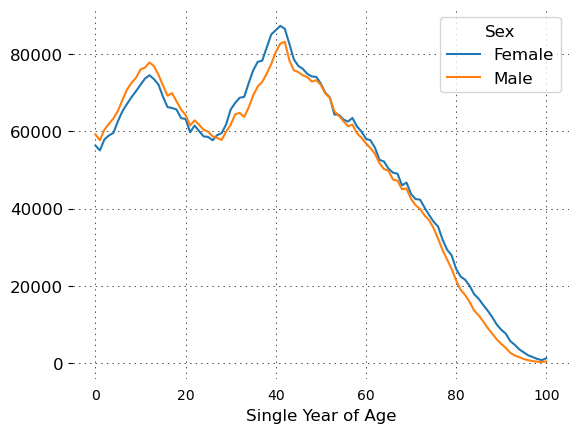

In [ ]:
# OK lets see thhis data on a graph
# A line plot with age on x-axis and age on Y-axis will do nicely for this, as most people intuitively read a progressing series from lowest on the left to higest on the right (for x axis(age)), and from lowest quantity of people on bottom, to highest value on top (for quantity). 
# A line graph is not *technically* accurate to represent the data we are given here, as we have ages only as whole/ integer-values (a bar chart would be more formally correct), but as ages are only counted in whole numbers, the likelyhood is that the distribution of the population between each integer point is evenly distributed, so a line chart is acceptable here, and is much more intuitive to read than a bar-chart for this application. 

#display the chart
df_anal.plot()

In [99]:
# Part 2: "Write code that would group the people within 5 years of that age together, into one age group."
# I interperate that this could mean two different solutions: 
# 1. Select only every 5 years: "X age +- 5 years", so for example of age 35 years this would group everybofy from age "35-5 = 30" to "35+5= 40". 
# 2  Select every single year of age, eg age 0, age 1, age 2, etc. This would efficeively be a lower resolution version of option 1. 

# Case 1: slice the age groups into 5 -year bundles. 
print(type(df_anal))
#Zero_Five = df_anal[df_anal[0]>35]

<class 'pandas.core.frame.DataFrame'>


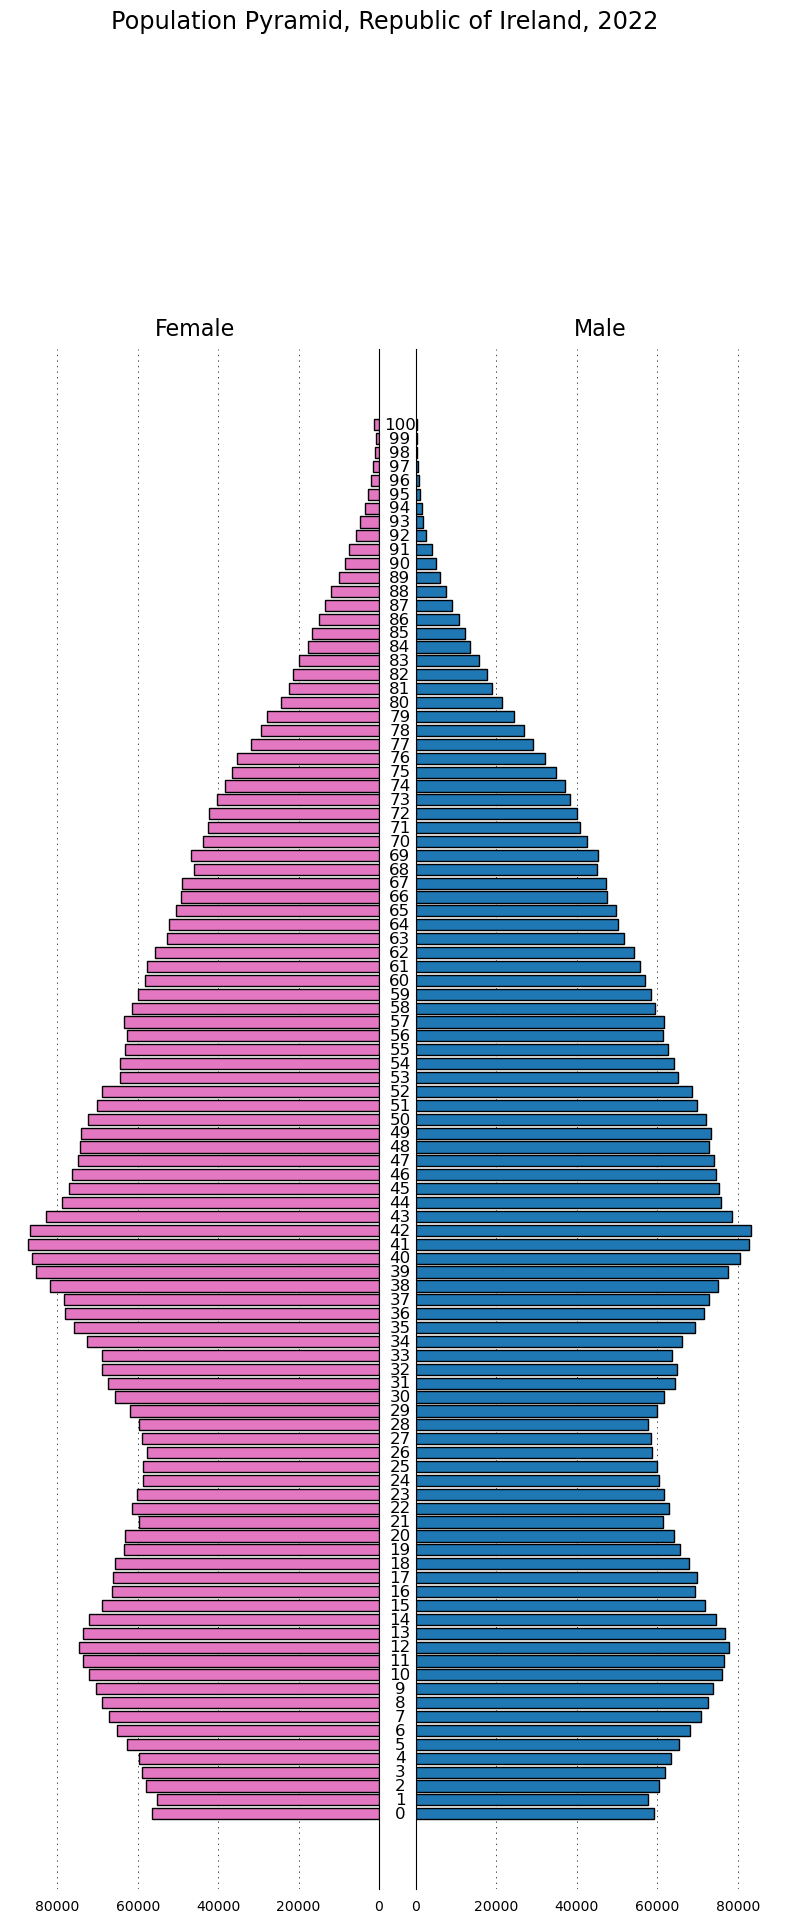

In [68]:
# a population pyramid is a very well known data reprsentation that displays the number of people alive at each single year of age in ascending order from the lowest value on the bottom of the graph, segregaed to display female and male on seperate sides of a central axis, upon which the labels for eahc age is positioned.  
# this section is basically lifted from Geoff Ruddock to see the Data as a butterfly plot https://geoffruddock.com/notebooks/data-viz/butterfly-charts/ 
# i would like to improve upon this graph by showing the difference/excess for each single year of age at the outside of the graph highlighted in a different colour etc. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # not actually used - remove if so. 

import matplotlib.ticker as mtick
import matplotlib.transforms as transforms


def butterfly_chart(
        data: pd.DataFrame, 
        title: str = None,
        middle_label_offset=0.0,
        figsize=(1,1),
        wspace=0.6
    ):

# this is all formatting for making the graph to be a pyramid graph
    plt.rcParams.update({
        # general
        'figure.facecolor': 'w',
        # font sizes
        'font.size': 12,
        'axes.titlesize': 16,
        'xtick.labelsize': 10,
        # force black border
        'patch.force_edgecolor': True,
        'patch.facecolor': 'black',
        # remove spines
        'axes.spines.bottom': False,
        'axes.spines.left': False,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.bottom': False,
        'xtick.top': False,
        'axes.titlepad': 10,
        # grid
        'axes.grid': True,
        'grid.color': 'k',
        'grid.linestyle': ':',
        'grid.linewidth': 0.5,
        'lines.dotted_pattern': [1, 3],
        'lines.scale_dashes': False
    })

    fig, (ax1, ax2) = plt.subplots(
        figsize=figsize,
        dpi=100,
        nrows=1,
        ncols=2,
        subplot_kw={'yticks': []},
        gridspec_kw={'wspace': wspace},
    )
    
    
    # plot the data
    (l1, x1), (l2,x2) = data.items()
    y = range(len(x1))
    labels = data.index.tolist()

    ax1.barh(y=y, width=x1, color='tab:pink', zorder=3)
    ax1.invert_xaxis()
    ax1.set_title(l1)

    ax2.barh(y=y, width=x2, color='tab:blue', zorder=3)
    ax2.set_title(l2)

    
    # forced shared xlim
    x_max = max(ax1.get_xlim()[0], ax2.get_xlim()[0])
    ax1.set_xlim((x_max, 0))
    ax2.set_xlim((0, x_max))
    
    # turn on axes spines on the inside y-axis
    ax1.spines['right'].set_visible(True)
    ax2.spines['left'].set_visible(True)
    
    # format axes
    xfmt = mtick.ScalarFormatter()
    ax1.xaxis.set_major_formatter(xfmt)
    ax2.xaxis.set_major_formatter(xfmt)

    # place center labels
    transform = transforms.blended_transform_factory(fig.transFigure, ax1.transData)
    for i, label in enumerate(labels):
        ax1.text(0.5+middle_label_offset, i, label, ha='center', va='center', transform=transform)

    plt.suptitle(title, y=1.05, fontsize='x-large')
    
    
butterfly_chart(
    df_anal,
    figsize=(10, 20),
    wspace=0.1,
    middle_label_offset=0.015,
    title='Population Pyramid, Republic of Ireland, 2022'
)


In [69]:
# For Calculating the sex gap at each age, i am going to implement the convention to subtract the number of males from the number of females. 
# This could have been done in either direction to get the difference, but as the gap changes from there being more males at younger ages 
# (due to a slightly higher proportion of births being male) to more females at older ages (Survivorship to old age is higher for females), 
# it is important to keep track of not only the magnitude of the discrepancy, but also its orientation.

# This section of code will perform subtraction operation on the values, and create new columns in the dataframe with values only if there is a positive value for excess population sex (negative discrepancies will be ignored). 
df_anal['Male_Excess'] = df_anal['Male']-df_anal['Female']
df_anal['Female_Excess'] = df_anal['Female']-df_anal['Male']
df_anal.clip(lower=0,inplace=True)
print(df_anal)

# this will give the result as a single column
# this satisfies the 2nd question in part 1 in assignmet 5: Age difference by sex. 
sex_gap_at_age = df_anal['Female']-df_anal['Male']
sex_gap_at_age

Sex                 Female   Male  Male_Excess  Female_Excess
Single Year of Age                                           
0                    56372  59220         2848              0
1                    55090  57750         2660              0
2                    57948  60472         2524              0
3                    58966  62002         3036              0
4                    59638  63372         3734              0
...                    ...    ...          ...            ...
96                    1912    654            0           1258
97                    1464    434            0           1030
98                     984    260            0            724
99                     672    210            0            462
100                   1168    308            0            860

[101 rows x 4 columns]


Single Year of Age
0     -2848
1     -2660
2     -2524
3     -3036
4     -3734
       ... 
96     1258
97     1030
98      724
99      462
100     860
Length: 101, dtype: int64

Now we have the excesses as seperate columns we shoudl be able to stack them outside the main data in the butterfly plot

calculate what the cumulative ages are 

In [70]:
cumages = df_anal[sex].mul(df_anal.index, axis = 0).sum()
cumages

202844406

In [71]:
# Assignment requirement - Weighted Mean
weighted_mean = cumages/number_people
weighted_mean

38.9397958987787

Weighted Median

In [72]:
cumsum = df_anal[sex].cumsum()
cumsum

Single Year of Age
0        56372
1       111462
2       169410
3       228376
4       288014
        ...   
96     5204892
97     5206356
98     5207340
99     5208012
100    5209180
Name: Female, Length: 101, dtype: int64

In [73]:
cutoff = df_anal[sex].sum()/2
cutoff

2604590.0

In [74]:
df_anal[sex][cumsum>=cutoff].index[0]

39

Weighted Standard Deviation

In [75]:
import numpy as np 
w_mean = np.average(df_anal.index, weights = df_anal[sex])
w_mean

38.9397958987787

In [76]:
w_variance = np.average((df_anal.index - w_mean)**2, weights = df_anal[sex])
w_variance

528.953520736661

In [77]:
w_std = np.sqrt(w_variance)
w_std

22.998989559036303